Optional if libraries arent installed yet:

In [5]:
%pip install numpy pandas matplotlib


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Disruption & Deviation Prediction — Week 1: Data Exploration
**Group X**

A short, focused look at the two procurement datasets (steel manufacturer **Company A**,
electrical engineering **Company B**). We answer the four Week-1 questions:

1. What does the data look like?
2. Which feature types are available?
3. How are delivery dates distributed?
4. Do suppliers differ in delivery behaviour?

Every helper function and every chart sits in its own cell, so each piece is small and easy to read.

## 1. Libraries
The standard data-science stack. `display` renders DataFrames nicely inside the loops further down.

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

## 2. Predefined functions
Just **three** small helpers, one per cell. For everything else we use built-in pandas
(`.head()`, `.dtypes`, `.isna()`, `crosstab`) instead of custom code — easier to read and to defend in the report.

**2.1 `load_procurement`** — reads one semicolon-separated CSV and turns the date columns into
real datetimes. `errors="coerce"` converts unparseable values to `NaT` instead of crashing.
The two files don't share all columns, so we only touch the dates that actually exist.

In [7]:
def load_procurement(path):
    df = pd.read_csv(path, sep=";")
    for col in ["Planned Delivery Date", "Arrival Date", "Original Desired Date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

**2.2 `add_delivery_features`** — builds the fields we want to predict later:
- `delay_days` = Arrival − Planned  (negative = early, 0 = on time, positive = late)
- `qty_diff`   = Delivered − Ordered quantity
- `status`     = `early` / `on_time` / `late`, with a separate **`open`** class for lines that
  have no arrival date yet. Keeping them separate is important — they are *not* "on time".

In [8]:
def add_delivery_features(df):
    df = df.copy()
    df["delay_days"] = (df["Arrival Date"] - df["Planned Delivery Date"]).dt.days
    df["qty_diff"]   = df["Delivered Quantity"] - df["Ordered Quantity"]

    def status(d):
        if pd.isna(d):  return "open"      # no arrival date yet -> not delivered
        if d > 0:       return "late"
        if d < 0:       return "early"
        return "on_time"

    df["status"] = df["delay_days"].apply(status)
    return df

**2.3 `supplier_summary`** — groups delivered lines by supplier and reports order count,
**median** delay (the median is robust against the corrupt dates we'll find in §6), and the
share of late deliveries. Suppliers with very few orders are dropped to avoid noise.

In [9]:
def supplier_summary(df, min_orders=30):
    delivered = df[df["status"] != "open"]
    g = delivered.groupby("Supplier")
    summary = pd.DataFrame({
        "orders":       g.size(),
        "median_delay": g["delay_days"].median(),
        "late_%":       (g["status"].apply(lambda s: (s == "late").mean()) * 100).round(1),
    })
    summary = summary[summary["orders"] >= min_orders]
    return summary.sort_values("orders", ascending=False)

## 3. Load Data
Set `DATA_DIR` to the folder with your CSVs, then load both companies and attach the derived fields.

In [10]:
DATA_DIR = Path('..') / 'data/raw'        # <-- adjust to your data folder
FILES = {
    "A": "Procurement_Data_Company_A_anonymized.csv",
    "B": "Procurement_Data_Company_B_anonymized.csv",
}

data = {}
for key, fname in FILES.items():
    df = load_procurement(DATA_DIR / fname)
    data[key] = add_delivery_features(df)
    print(f"Company {key}: {data[key].shape[0]} rows, {data[key].shape[1]} columns")

Company A: 9194 rows, 14 columns
Company B: 18078 rows, 15 columns


## 4. What does the data look like?
First a glance at the raw rows, then the feature types and missing values.

In [11]:
for name, df in data.items():
    print(f"--- Company {name} ---")
    display(df.head(3))

--- Company A ---


,Order Number,Order Position,Supplier,Ordered Product,Product Article Number,End Product,Planned Delivery Date,Arrival Date,Ordered Quantity,Delivered Quantity,Quality,delay_days,qty_diff,status
0,74682,11,41781068,V-Flansch,3000.0,NaN,2023-01-05,2022-12-15,3.0,3.0,3.1,-21.0,0.0,early
1,74682,11,41781068,V-Flansch,3000.0,NaN,2023-01-05,2022-12-15,3.0,3.0,3.1,-21.0,0.0,early
2,74682,11,41781068,V-Flansch,3000.0,NaN,2023-01-05,2022-12-15,3.0,3.0,3.1,-21.0,0.0,early


--- Company B ---


,Order Number,Supplier Number,Supplier,Product Article Number,Ordered Product,Ordered Product - Supplement,Original Ordered Quantity,Original Desired Date,Planned Delivery Date,Ordered Quantity,Arrival Date,Delivered Quantity,delay_days,qty_diff,status
0,6260783,70214,93118673,23101030601,Halteplatte für OPC-Schnittstelle,REOVIB [CODE] [CODE],14.0,2023-05-01,2023-05-01,14.0,2023-05-23,14.0,22.0,0.0,late
1,6260784,70175,41446825,23100770000,"Gehäuse [CODE]/[NUM] [NUM], A [NUM]",Alu-/Gussgehäuse,50.0,2023-09-04,2023-09-04,50.0,2023-09-04,50.0,0.0,0.0,on_time
2,6260785,72156,22740983,23101070000,Gehäuse kpl. [CODE] rf Z.Nr.:[CODE]-[CODE],[NUM],30.0,2023-08-21,2023-08-21,30.0,2023-08-24,30.0,3.0,0.0,late


**Feature types & missing values.** Note that `Order Number`, `Supplier` and
`Product Article Number` are stored as numbers but are **identifiers** — categorical, not numeric.
The many missing `Arrival Date` / `Delivered Quantity` values are exactly the **open** orders
(not yet delivered), which is why we gave them their own status class.

In [21]:
for name, df in data.items():
    print(f"===== Company {name} =====")
    print(df.dtypes, "\n")
    print("Missing values:")
    print(df.isna().sum(), "\n")
    print("Duplicate rows:")
    print(df.duplicated().sum(), "\n")
    #1. Count corrupted numbers (text/dates hiding in quantity columns)
    bad_qty = (df['Ordered Quantity'].notna() & pd.to_numeric(df['Ordered Quantity'], errors='coerce').isna()).sum()
    
    # 2. Count corrupted dates (text/numbers hiding in date columns)
    bad_planned = (df['Planned Delivery Date'].notna() & pd.to_datetime(df['Planned Delivery Date'], errors='coerce').isna()).sum()
    bad_arrival = (df['Arrival Date'].notna() & pd.to_datetime(df['Arrival Date'], errors='coerce').isna()).sum()
    # Print the summaries
    print(f"Corrupted 'Ordered Quantity' entries: {bad_qty}")
    print(f"Corrupted 'Planned Delivery Date' entries: {bad_planned}")
    print(f"Corrupted 'Arrival Date' entries: {bad_arrival}\n")

===== Company A =====
Order Number                       int64
Order Position                     int64
Supplier                           int64
Ordered Product                      str
Product Article Number           float64
End Product                          str
Planned Delivery Date     datetime64[us]
Arrival Date              datetime64[us]
Ordered Quantity                 float64
Delivered Quantity               float64
Quality                              str
delay_days                       float64
qty_diff                         float64
status                               str
dtype: object 

Missing values:
Order Number                 0
Order Position               0
Supplier                     0
Ordered Product              2
Product Article Number     544
End Product               5974
Planned Delivery Date        0
Arrival Date              2893
Ordered Quantity             0
Delivered Quantity        2893
Quality                   6118
delay_days                2893


## 5. The prediction target: delivery status
This is the label we will model in the coming weeks, so its balance matters.

In [22]:
for name, df in data.items():
    print(f"--- Company {name} ---")
    display(df["status"].value_counts())

--- Company A ---


status
late       3380
open       2893
early      1977
on_time     944
Name: count, dtype: int64

--- Company B ---


status
late       8447
early      5356
on_time    2223
open       2052
Name: count, dtype: int64

**Chart: status distribution** (both companies). Late deliveries dominate, early is sizeable,
and a meaningful chunk is still open — a clearly imbalanced, multi-class target.

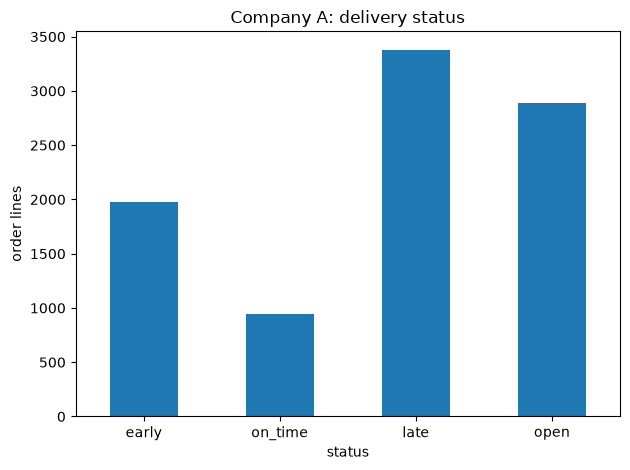

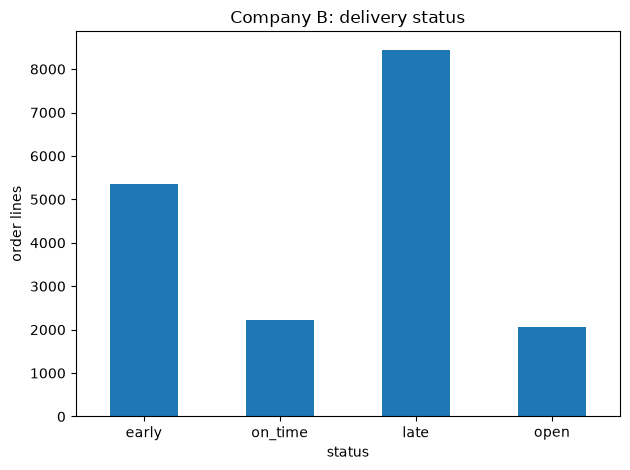

In [23]:
for name, df in data.items():
    df["status"].value_counts().reindex(["early", "on_time", "late", "open"]).plot(
        kind="bar", rot=0, title=f"Company {name}: delivery status")
    plt.ylabel("order lines"); plt.tight_layout(); plt.show()

## 6. How are delivery dates distributed?

**Chart: deliveries per month** — shows the active period and any seasonality / backlog.

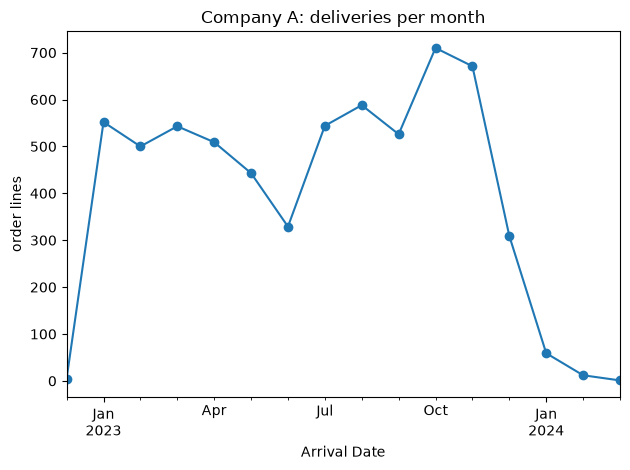

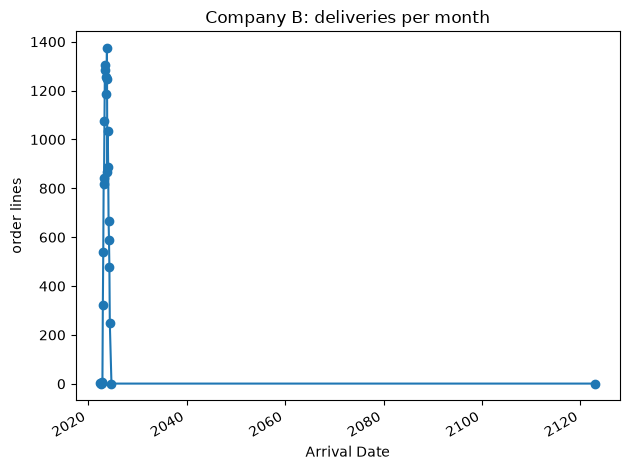

In [24]:
for name, df in data.items():
    monthly = df["Arrival Date"].dropna().dt.to_period("M").value_counts().sort_index()
    monthly.index = monthly.index.to_timestamp()
    monthly.plot(marker="o", title=f"Company {name}: deliveries per month")
    plt.ylabel("order lines"); plt.tight_layout(); plt.show()

**Chart: delay distribution** (clipped to ±30 days for readability). Most deliveries cluster
tightly around zero.

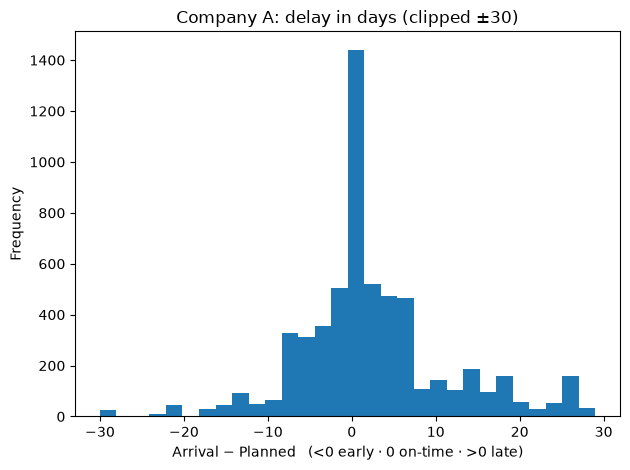

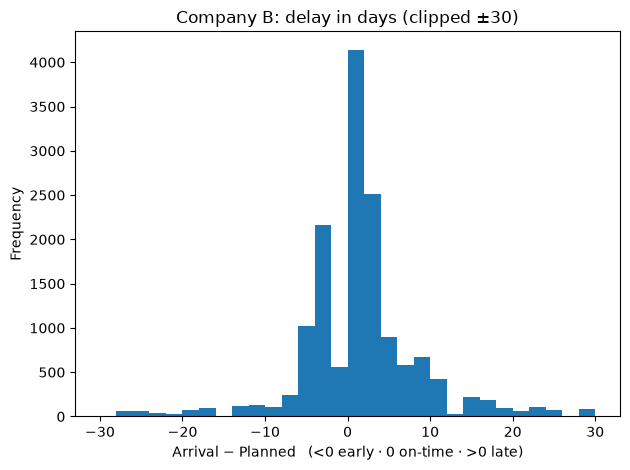

In [25]:
for name, df in data.items():
    d = df["delay_days"].dropna()
    d[d.between(-30, 30)].plot(kind="hist", bins=30,
        title=f"Company {name}: delay in days (clipped ±30)")
    plt.xlabel("Arrival − Planned   (<0 early · 0 on-time · >0 late)")
    plt.tight_layout(); plt.show()

**Key finding — zero-inflation.** A large share of deliveries land *exactly* on time and at
*exactly* the ordered quantity. That spike at zero is why a plain regression struggles here and
why the brief points to **zero-inflated / two-stage models** (first: is there a deviation at all?
then: how large?).

In [26]:
for name, df in data.items():
    delivered = df[df["status"] != "open"]
    on_time = (delivered["delay_days"] == 0).mean() * 100
    exact   = (delivered["qty_diff"]   == 0).mean() * 100
    print(f"Company {name}: {on_time:.0f}% delivered exactly on time, "
          f"{exact:.0f}% in exactly the ordered quantity")

Company A: 15% delivered exactly on time, 99% in exactly the ordered quantity
Company B: 14% delivered exactly on time, 97% in exactly the ordered quantity


**Data-quality flag.** Company B contains corrupt dates (e.g. a planned date in the year 4444),
which distort any mean-based statistic — another reason we report the **median** delay above.
Decide with the chair whether to drop or correct these rows.

In [27]:
for name, df in data.items():
    s = df["Planned Delivery Date"]
    bad = s.notna() & ~s.between("2018-01-01", "2026-12-31")
    print(f"Company {name}: {int(bad.sum())} implausible planned dates "
          f"(range {s.min().date()} .. {s.max().date()})")

Company A: 0 implausible planned dates (range 2023-01-04 .. 2023-12-21)
Company B: 109 implausible planned dates (range 2020-05-18 .. 4444-10-31)


## 7. Do suppliers differ?
If delivery behaviour varies by supplier, the supplier is a strong predictor for the model.

In [28]:
for name, df in data.items():
    print(f"--- Company {name}: top suppliers by volume ---")
    display(supplier_summary(df).head(8))

--- Company A: top suppliers by volume ---


,orders,median_delay,late_%
Supplier,,,
38894112,763,2.0,55.2
62658211,435,0.0,48.5
33444489,421,18.0,79.1
63601445,403,-1.0,44.9
49689366,365,0.0,46.6
41781068,248,0.0,48.0
12980207,248,-2.0,31.5
38624001,179,-4.0,36.3


--- Company B: top suppliers by volume ---


,orders,median_delay,late_%
Supplier,,,
52391922,889,-3.0,12.9
49166303,578,2.0,82.4
93118673,536,-6.0,37.1
95947983,505,0.0,23.2
79078827,437,4.0,85.4
42986849,422,6.0,78.2
22740983,357,1.0,77.0
85212855,356,0.0,48.0


**Chart: status mix per supplier** (top 10 by volume). The bars make the differences obvious —
some suppliers are reliably on time, others chronically late.

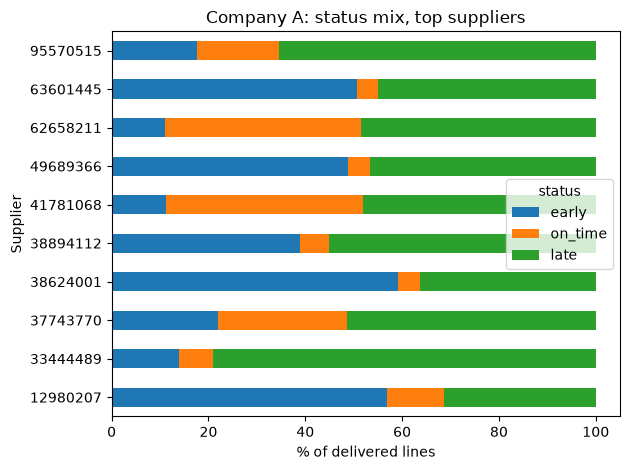

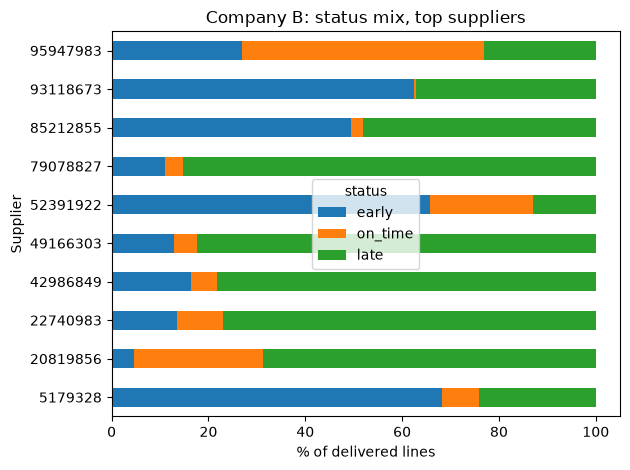

In [29]:
for name, df in data.items():
    top = supplier_summary(df).head(10).index
    sub = df[df["Supplier"].isin(top) & (df["status"] != "open")]
    mix = pd.crosstab(sub["Supplier"], sub["status"], normalize="index")
    mix = mix.reindex(columns=["early", "on_time", "late"], fill_value=0) * 100
    mix.plot(kind="barh", stacked=True, title=f"Company {name}: status mix, top suppliers")
    plt.xlabel("% of delivered lines"); plt.tight_layout(); plt.show()

## 8. Week-1 takeaways
- **Data:** A ≈ 9.2k lines, B ≈ 18k lines, mostly 2023. Columns differ between the two companies.
- **Feature types:** identifiers (order/supplier/article numbers), numeric quantities,
  datetimes, free-text product names, and a quality code for A only.
- **Missing arrivals** = open orders → kept as their own status, not silently dropped.
- **Zero-inflated target:** strong spike at zero delay and zero quantity deviation → motivates
  two-stage / zero-inflated modelling.
- **Suppliers matter:** late-rate varies strongly by supplier → a key categorical feature.
- **Open issues:** corrupt dates in B; how to treat `tolerance` for "on time"; B's production-site
  code inside the order number.

> Replace these with your own numbers from the cells above for the report.